In [ ]:
import os
from pathlib import Path
import torch
from torchvision import transforms
import configparser
from tqdm import tqdm

In [2]:
data_path = Path(os.getcwd()).parent

In [3]:
# listado de imagenes para cada dataset
data_config = configparser.ConfigParser()
data_config.read(data_path/'data/splits/global_binaria.ini')

['c:\\Users\\gabim\\MiM\\data\\splits\\global_binaria.ini']

# Media y desvío de intensidad para cada canal

In [4]:
images_path = data_config['split'].get('training').split(sep=',')
count = len(images_path)*512*512

In [5]:
to_tensor = transforms.ToTensor() # esta transformacion aplica torch.tensor, deja las intensidades en el rango de 0 a 1 si ve que la entrada es de 0 a 255
                                  # y acomoda los indices como espera recibirlos pytorch (canales,alto,ancho)

sum_by_channel = torch.zeros(3) # creo un tensor de ceros para guardar la media de los 3 canales

for image in tqdm(images_path):
    img = cv2.imread(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1).sum(dim=1) # en la primera dimension que son los canales le pedimos que queden los 3 pero el resto de las dimensiones (alto, ancho)
                                    # le pedimos que las apile en una dimension y que sume las intensidades de cada canal
    sum_by_channel += img


img_mean = sum_by_channel/count
img_mean

100%|██████████| 41978/41978 [08:35<00:00, 81.48it/s]


tensor([0.1948, 0.2880, 0.4238])

In [6]:
sum_desv_by_channel = torch.zeros(3)

for image in tqdm(images_path):
    img = cv2.imread(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1)
    img = (img - img_mean.view(3,1))**2
    img = img.sum(dim=1)
    sum_desv_by_channel += img

img_std = (sum_desv_by_channel/count)**0.5
img_std

100%|██████████| 41978/41978 [03:02<00:00, 229.77it/s]


tensor([0.1661, 0.2021, 0.2782])

# Clase Dataset

In [91]:
from pathlib import Path
import torch
from torchvision import transforms
from torch.utils.data import Dataset
import configparser
from PIL import Image



class EyeDataset(Dataset):
  
  def __init__(self, data_path, partition, mean, std, transformations=None):
    '''
    - data_path: ruta base donde están las imágenes y configuraciones
    - partition: 'training', 'validation' o 'test'
    - mean: media para normalizar los datos
    - std: desvío estándar
    - transformations: la lista de transformaciones a aplicar al dataset de train
    '''

    # chequeo que no entre cualquier cosa en vez de partition
    assert partition in ['training', 'validation', 'test'], 'partition has to be training, validation or test, not {}'.format(partition)

    # transformaciones
    data_transforms = [transforms.ToTensor(),
                       transforms.Normalize(mean=mean, std=std)]
    
    if (partition == 'training') and not (transformations is None):
      data_transforms = transformations + data_transforms
      
    self.data_transforms = transforms.Compose(data_transforms)
    
    self.data_path = Path(data_path)

    # listado de imagenes para cada dataset
    data_config = configparser.ConfigParser()
    data_config.read(self.data_path/'data/splits/global_binaria.ini')

    # listado de labels para cada imagen
    labels_config = configparser.ConfigParser()
    labels_config.read(self.data_path/'data/labels/global_labels.ini')

    self.data = [(image, int(labels_config['label'].get(image)))
                  for image in data_config['split'].get(partition).split(sep=',')
                  ]
    
    # hacemos una lista de nombres para las clases
    self.class_names = ['buena', 'mala']


  def __len__(self):
    '''
    Método que devuelve la cantidad de elementos del dataset
    '''
    return len(self.data)
  
  def __getitem__(self, index):
    '''
    Método que devuelve el elemento index del dataset
    '''
    # obtengo la ruta de la imagen y su etiqueta asociada
    img_path, label = self.data[index]

    # cargo la imagen
    img = Image.open(self.data_path/'data/images'/(img_path+'.png')).convert("RGB") # uso PIL porque es compatible con transforms. Importa la imagen en el formato que espera pytorch 
                                                                                    # y aclaro RGB porque PIL importa en el formato original y puede no ser RGB qu es lo que espera pytorch
    # transformaciones
    img = self.data_transforms(img)

    # convierto la etiqueta en un tensor de tipo long
    label = torch.tensor(label, dtype=torch.long)

    # retornamos el par
    return (img, label)

In [73]:
mean=torch.tensor([0.1948, 0.2880, 0.4238])
std=torch.tensor([0.1661, 0.2021, 0.2782])

In [92]:
transformations = [transforms.RandomHorizontalFlip(p=0.5),
                   transforms.RandomRotation(degrees=[-15,15], interpolation=transforms.InterpolationMode.BILINEAR,fill=(0, 0, 0)),
                   transforms.RandomVerticalFlip(p=0.5),
                   # transforms.RandomResizedCrop(size=512, scale=(0.8, 1.0))
                   ]


train = EyeDataset(data_path=Path(os.getcwd()).parent,
                   partition='training',
                   mean=mean,
                   std=std,
                   transformations=transformations)


In [93]:
len(train)

41978

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5233644..3.5727592].


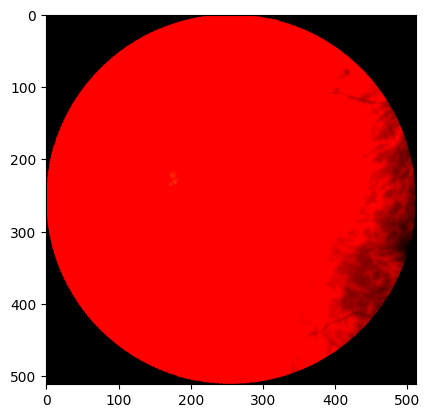

In [94]:
import matplotlib.pyplot as plt

img,label = train[0]

plt.imshow(img.permute(1,2,0))

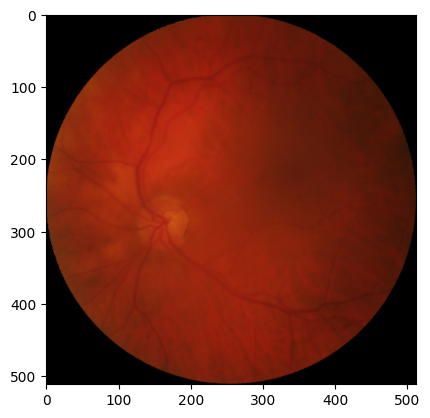

In [95]:
import matplotlib.pyplot as plt

img,label = train[0]

plt.imshow(img.permute(1,2,0)* std + mean)

In [96]:
torch.min(train[0][0]), torch.max(train[0][0])

(tensor(-1.5234), tensor(3.5728))

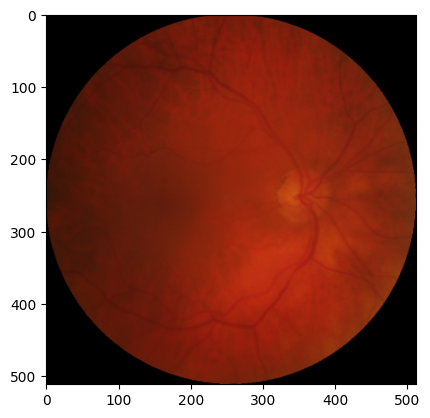

In [97]:
from torchvision import transforms
from PIL import Image

img=Image.open(train.data_path/'data/images'/(train.data[0][0]+'.png')).convert("RGB") 
# armamos una lista de transformaciones
transformations = [
   transforms.RandomRotation(degrees=[-15,15], interpolation=transforms.InterpolationMode.BILINEAR,fill=(0, 0, 0))
                   ]
# y creamos una composición
composed_transformation = transforms.Compose(transformations)

# aplicamos la sucesión de transformaciones y graficamos el resultado
img_transformed = composed_transformation(img)
plt.imshow(img_transformed)
plt.show()